# 03 · EDA — FAO FAOSTAT (Producción Agrícola)
Análisis exploratorio de datos de producción agrícola para Bolivia y Colombia.  
**Fuente:** FAO FAOSTAT API (`download_faostat.py`)  
**Archivo:** `data/external/faostat/faostat_production.csv`

Productos: Soybeans, Cattle, Sugar cane, Oil palm fruit  
Elementos: `production_tonnes`, `area_harvested_ha`

## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

FAO_CSV = Path('../data/external/faostat/faostat_production.csv')
RES     = Path('../data/results'); RES.mkdir(parents=True, exist_ok=True)

if not FAO_CSV.exists():
    raise FileNotFoundError(f'Ejecuta scripts/download_faostat.py primero. Esperado: {FAO_CSV}')

df = pd.read_csv(FAO_CSV)
print(f'Filas: {len(df):,} | Columnas: {list(df.columns)}')
df.head()

Filas: 60 | Columnas: ['country_code', 'country_name', 'year', 'item_name', 'element', 'value', 'unit']


,country_code,country_name,year,item_name,element,value,unit
0,BOL,Bolivia (Plurinational State of),2015,Sugar cane,area_harvested_ha,145449.0,ha
1,BOL,Bolivia (Plurinational State of),2016,Sugar cane,area_harvested_ha,146009.0,ha
2,BOL,Bolivia (Plurinational State of),2017,Sugar cane,area_harvested_ha,157074.0,ha
3,BOL,Bolivia (Plurinational State of),2018,Sugar cane,area_harvested_ha,168180.0,ha
4,BOL,Bolivia (Plurinational State of),2019,Sugar cane,area_harvested_ha,174630.0,ha


## 1. Estructura y calidad

In [2]:
print('Tipos:')
print(df.dtypes)
print('\nNulos:')
print(df.isnull().sum())
print('\nProductos disponibles:')
print(df['item_name'].unique())
print('\nElementos:')
print(df['element'].unique())
print('\nPaíses:')
print(df['country_code'].unique())
print('\nRango años:')
print(df['year'].min(), '→', df['year'].max())

Tipos:
country_code        str
country_name        str
year              int64
item_name           str
element             str
value           float64
unit                str
dtype: object

Nulos:
country_code    0
country_name    0
year            0
item_name       0
element         0
value           0
unit            0
dtype: int64

Productos disponibles:
<StringArray>
['Sugar cane', 'Oil palm fruit']
Length: 2, dtype: str

Elementos:
<StringArray>
['area_harvested_ha', 'production_tonnes']
Length: 2, dtype: str

Países:
<StringArray>
['BOL', 'COL']
Length: 2, dtype: str

Rango años:
2015 → 2024


## 2. Producción por cultivo y país

In [3]:
prod = df[df['element'] == 'production_tonnes'].copy()
prod_pivot = prod.pivot_table(index=['country_code', 'year'],
                               columns='item_name', values='value').reset_index()
print('Producción (toneladas) — primeras filas:')
prod_pivot.head(8)

Producción (toneladas) — primeras filas:


item_name,country_code,year,Oil palm fruit,Sugar cane
0,BOL,2015,NaN,7192512.00
1,BOL,2016,NaN,7374751.00
2,BOL,2017,NaN,8731675.50
3,BOL,2018,NaN,9616439.95
4,BOL,2019,NaN,9558472.00
5,BOL,2020,NaN,10094423.00
6,BOL,2021,NaN,10057104.09
7,BOL,2022,NaN,9659111.34


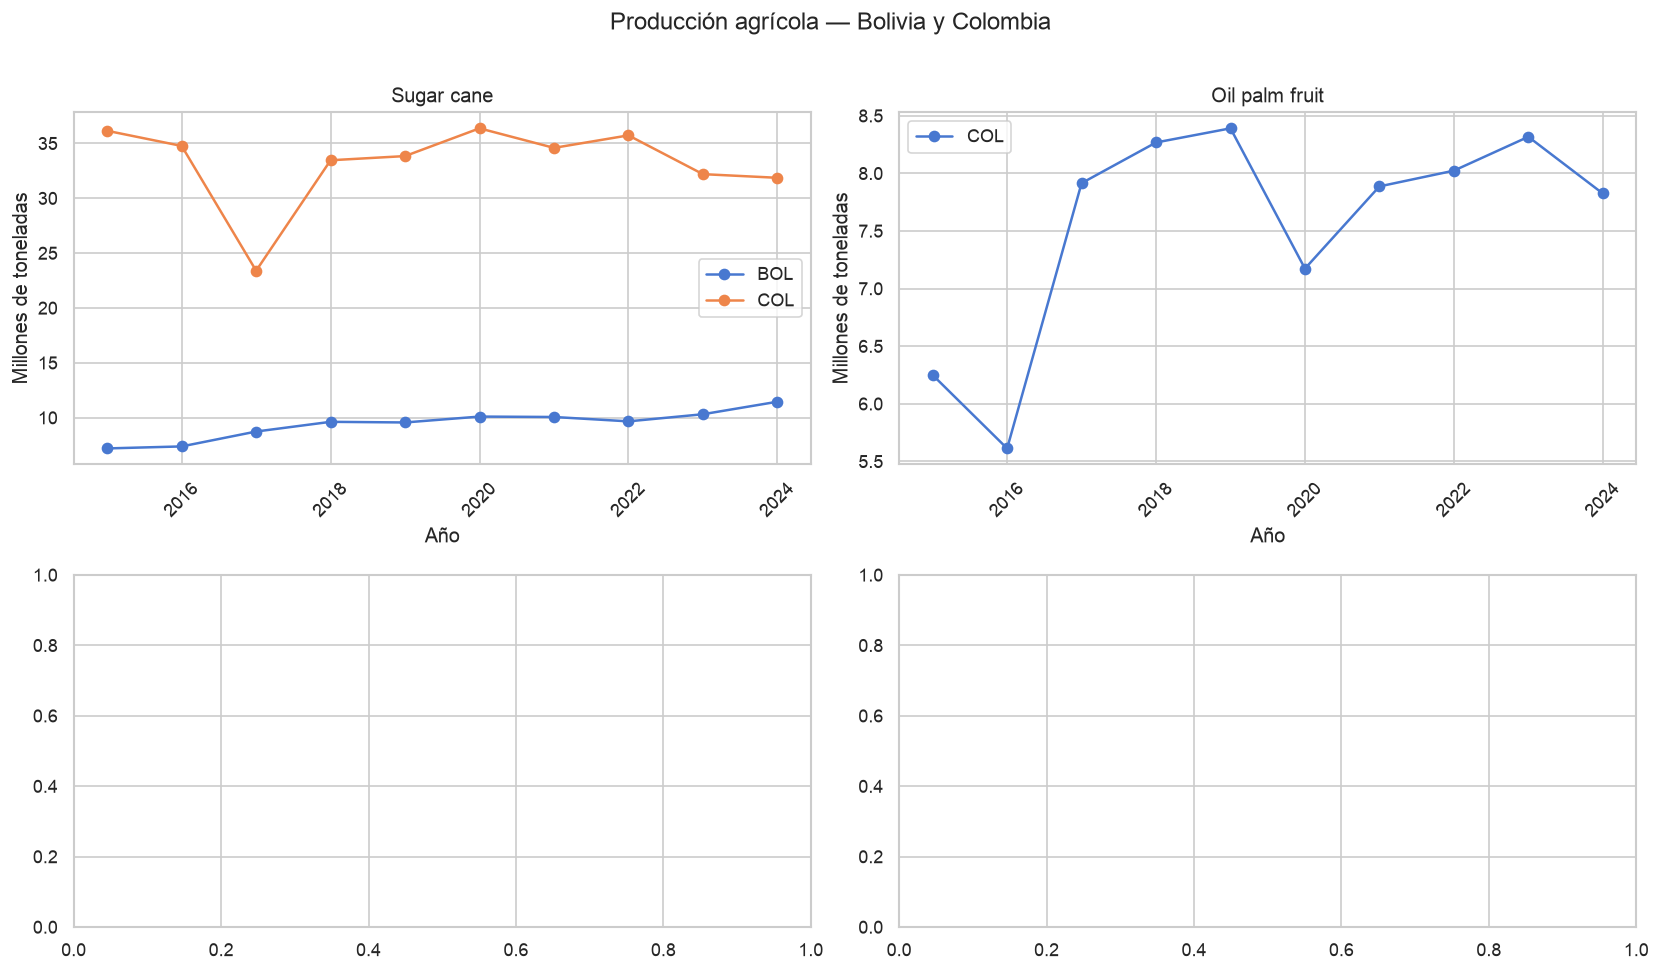

In [4]:
items = df['item_name'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, item in zip(axes, items):
    sub = df[(df['item_name'] == item) & (df['element'] == 'production_tonnes')]
    for country, grp in sub.groupby('country_code'):
        grp_s = grp.sort_values('year')
        ax.plot(grp_s['year'], grp_s['value'] / 1e6, marker='o', label=country)
    ax.set_title(item)
    ax.set_xlabel('Año')
    ax.set_ylabel('Millones de toneladas')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Producción agrícola — Bolivia y Colombia', y=1.01)
plt.tight_layout()
plt.savefig(RES / 'eda_faostat_produccion.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Área cosechada — presión sobre el territorio

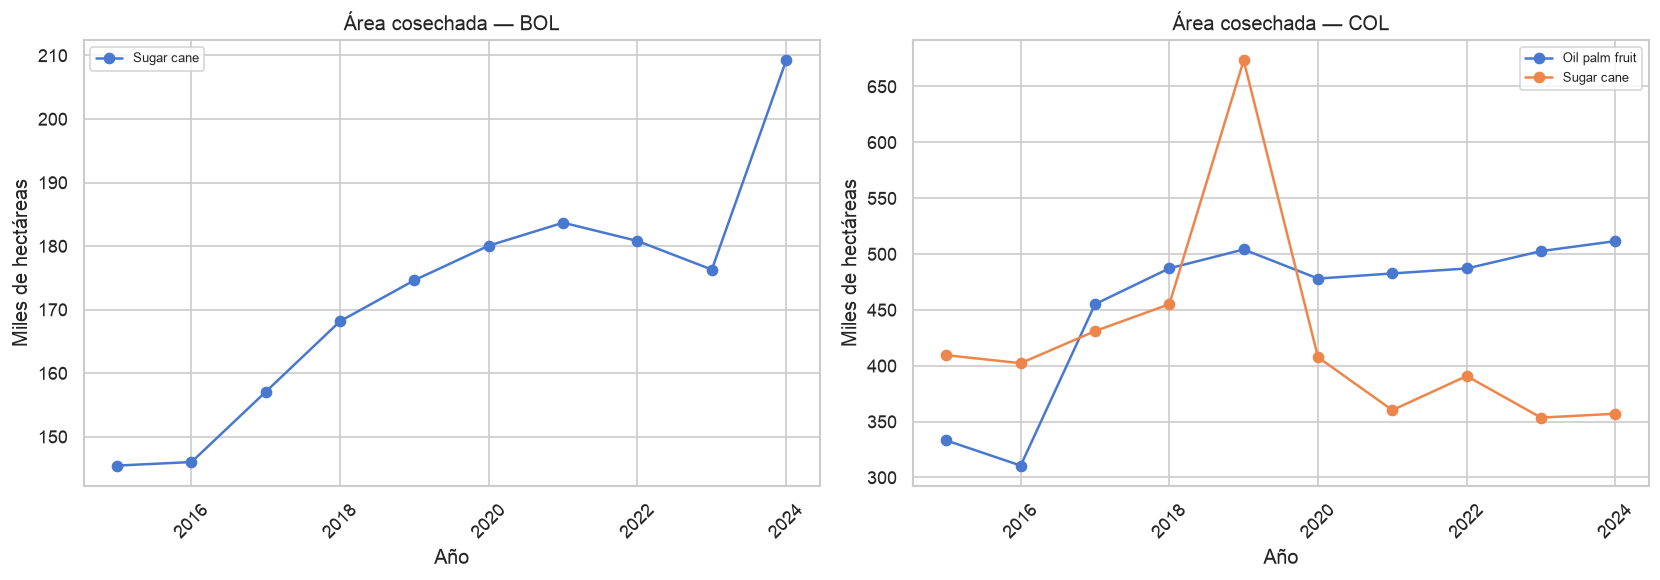

In [5]:
area = df[df['element'] == 'area_harvested_ha'].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, country in zip(axes, ['BOL', 'COL']):
    sub = area[area['country_code'] == country]
    for item, grp in sub.groupby('item_name'):
        grp_s = grp.sort_values('year')
        ax.plot(grp_s['year'], grp_s['value'] / 1e3, marker='o', label=item)
    ax.set_title(f'Área cosechada — {country}')
    ax.set_xlabel('Año')
    ax.set_ylabel('Miles de hectáreas')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RES / 'eda_faostat_area_cosechada.png', dpi=120)
plt.show()

## 4. Hallazgos y decisiones de transformación

| Hallazgo | Decisión |
|----------|----------|
| Soya domina el área cosechada en Bolivia (>1M ha) | Cruzar con `is_soy_area` de alertas GFW |
| Ganadería (cattle) no tiene área cosechada, solo producción | Usar producción como proxy de presión ganadera |
| Palma de aceite crece sostenidamente en Colombia | Correlacionar con alertas en departamentos productores |
| Datos anuales sin nulos para 2015–2024 | Usar directamente; granularidad país-año |
| Unidades heterogéneas (t, ha) | Normalizar por país antes de correlacionar con alertas |